[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/maduakordavid01-ui/O.Rproject/blob/main/solar_project_panel_detection%20(1).ipynb
)


In [1]:
!pip install roboflow
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 145.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.3 MB/s eta 0:00:00


In [2]:
from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import files
files.upload()   # choose the .zip

Saving id.v1-1.yolov11.zip to id.v1-1.yolov11 (1).zip


{'id.v1-1.yolov11 (1).zip': b'PK\x03\x04\x14\x03\x00\x00\x08\x00/j3\\p\xd7\x86\x95g\x00\x00\x00m\x00\x00\x00\x12\x00\x00\x00README.dataset.txt-\xcb\xbb\x0e\xc20\x0c\x05\xd0\xdd_q%f\x12\x90\x98:0\xd0\x95\x01\xb11&\xb5\x01Km\x0cq\x1f\xea\xdfw\xe9\xd9\xcf\x01\xca\xb8\xe2L\xdfq\xfcy\x13\xe3Tt\x96\xea\x12\xaae{\xf7\xb6\x84\xce\x86\x98\xfb\xf4gM\x83\x15\x8e\xca\xc7\xcfb\xeaD\x8fj\xb3\xb20\xf2\x8a\x84\xe7\x1e0\xb9T\xbak\'\xc5\xa5A\xdb\xe2\xf6\xc2%\x9c\x886PK\x03\x04\x14\x03\x00\x00\x08\x00/j3\\%Xjrr\x02\x00\x00\xbf\x04\x00\x00\x13\x00\x00\x00README.roboflow.txt}S\xdbn\x131\x10}\xf7W\xcc\x0b\x88\x96\xdc6\xe5"*\xf1\x80\x10E \xaa\xa2\xb6B\xf0\x84\x9c\xddI\xd6\xd4\xb1-{6i\xfaU|\x03_\xc6\xb1\xb3Io\x88H\xabx\xed\xf19g\xce\x9cU\xa6\xa1!\xad*\xaa\xd4\xdb\xff\xfe\x94\xbalM\xa2F\x8bN,\xb4\xd6\x89\xf8:\xf8(\xdc\xd0\xcah\x8a~\xe6\xe7\xd6\xafG\xb5_\x92w\xf4Y\xbbN\xc7\rUo\x064\x9dL_\x91\x16\xaa\x8e\xab\xd7\xf4\xf5\x94>\x9e^*u\xde_ \xa0jG\xec\x9a\xa1\xf8!\xfe\x08\x08\xa1\x13\x8e\xc0M\x06P\xc1j\x99\xfb\xb8$i

In [4]:
import zipfile, os

zip_path = "//content/id.v1-1.yolov11.zip"   # change this
out_dir = "/content/roboflow_dataset"

os.makedirs(out_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(out_dir)

print("Extracted to:", out_dir)

Extracted to: /content/roboflow_dataset


Num train images: 12


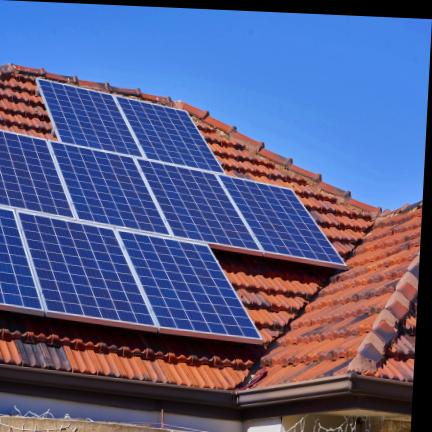

In [5]:
from pathlib import Path
from PIL import Image

root = Path(out_dir)
img_paths = sorted((root / "train" / "images").glob("*.*"))
print("Num train images:", len(img_paths))

Image.open(img_paths[0])

In [6]:
import os
for r, d, f in os.walk("/content/roboflow_dataset"):
    if r.endswith("images"):
        print(r, "->", len(f), "files")

/content/roboflow_dataset/valid/images -> 1 files
/content/roboflow_dataset/train/images -> 12 files


In [7]:
rf = Roboflow(api_key="YQ6y3A5WjPFUPFZ477nw")
project = rf.workspace("blaqdiamond").project("id-gwois")

print(f"Available versions for project '{project.name}':")
for v in project.versions():
    print(f"- Version {v.version}: {v.name}")

# IMPORTANT: After seeing the available versions, please replace <YOUR_VALID_VERSION_NUMBER_OR_NAME_HERE> with a valid one.
# For example: version = project.version(1) or version = project.version('my_dataset_v1')
# Then uncomment the following two lines:
# version = project.version(<YOUR_VALID_VERSION_NUMBER_OR_NAME_HERE>)
# dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...
Available versions for project 'id':
- Version 1: id


In [18]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
metrics = model.val()
print(metrics)

Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco.yaml' images not found, missing path '/content/datasets/coco/val2017.txt'
Unzipping /content/datasets/coco2017labels-segments.zip to /content/datasets/coco...: 100% ━━━━━━━━━━━━ 122232/122232 6.0Kfiles/s 20.4s
Unzipping /content/datasets/coco/images/val2017.zip to /content/datasets/coco/images/val2017...: 100% ━━━━━━━━━━━━ 5001/5001 334.8files/s 14.9s
Unzipping /content/datasets/coco/images/test2017.zip to /content/datasets/coco/images/test2017...: 100% ━━━━━━━━━━━━ 40671/40671 407.4files/s 1:40
Unzipping /content/datasets/coco/images/train2017.zip to /content/datasets/coco/images/train2017...: 100% ━━━━━━━━━━━━ 118288/118288 449.3files/s 4:23
Dataset download success ✅ (827.3s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 61.8±24.2 MB/s, size: 210.6 KB)
val: Scannin

In [19]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1402.4±278.8 MB/s, size: 169.5 KB)
val: Scanning /content/datasets/coco/labels/val2017.cache... 4952 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5000/5000 1.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 313/313 5.0it/s 1:03
                   all       5000      36335      0.634      0.475      0.521      0.371
                person       2693      10777      0.755      0.671      0.745      0.514
               bicycle        149        314       0.69      0.392      0.457      0.264
                   car        535       1918      0.648      0.514      0.562      0.365
            motorcycle        159        367      0.715       0.58      0.659      0.414
              airplane         97        143      0.814      0.764      0.834      0.653
                   bus      

In [22]:
from ultralytics import YOLO

# Load model
model = YOLO("yolov8n.pt")

# Validate on YOUR dataset (not COCO)
metrics = model.val(data="/content/roboflow_dataset/data.yaml")
print(metrics)

Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8.7±0.0 MB/s, size: 49.6 KB)
val: Scanning /content/roboflow_dataset/valid/labels... 1 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 455.1it/s 0.0s
val: New cache created: /content/roboflow_dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 9.3it/s 0.1s
                   all          1          1     0.0667          1     0.0663     0.0199
                person          1          1     0.0667          1     0.0663     0.0199
Speed: 1.4ms preprocess, 80.4ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val6
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric obje

Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1608.5±469.9 MB/s, size: 138.8 KB)
val: Scanning /content/datasets/coco/labels/val2017.cache... 4952 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5000/5000 2.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 313/313 5.1it/s 1:01
                   all       5000      36335      0.634      0.475      0.521      0.371
                person       2693      10777      0.755      0.671      0.745      0.514
               bicycle        149        314       0.69      0.392      0.457      0.264
                   car        535       1918      0.648      0.514      0.562      0.365
            motorcycle        159        367      0.715       0.58      0.659      0.414
              airplane         97  

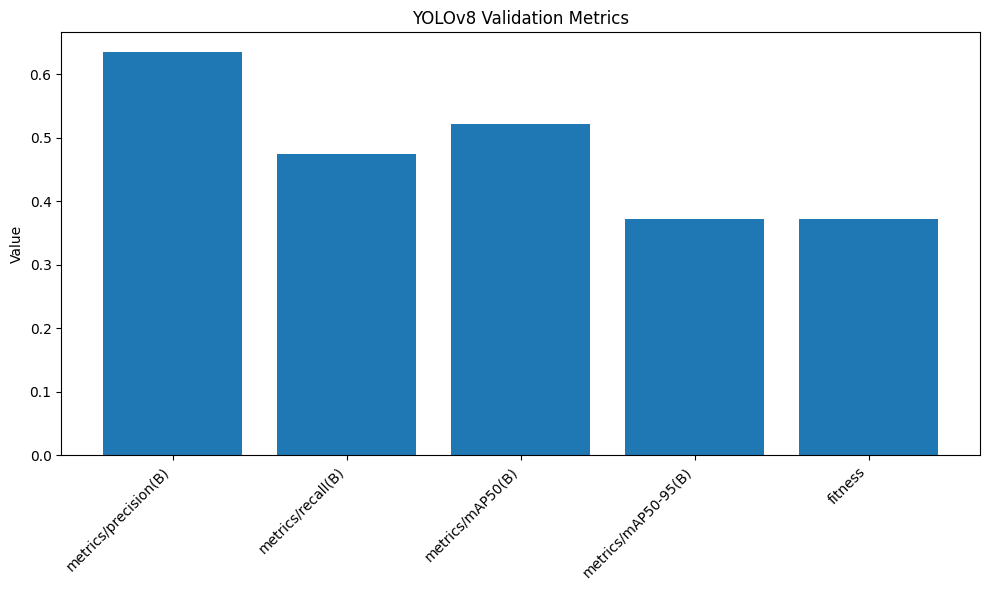


=== VALIDATION RESULTS ===
metrics/precision(B): 0.6343
metrics/recall(B): 0.4746
metrics/mAP50(B): 0.5212
metrics/mAP50-95(B): 0.3714
fitness: 0.3714


In [25]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. Validate model
model = YOLO("yolov8n.pt")
metrics = model.val()  # Change to YOUR data if needed

# 2. Get the metrics dictionary
metrics_dict = metrics.results_dict

# 3. Create visualization
plt.figure(figsize=(10, 6))
plt.bar(list(metrics_dict.keys()), list(metrics_dict.values()))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Value')
plt.title('YOLOv8 Validation Metrics')
plt.tight_layout()
plt.show()

# 4. Print metrics nicely
print("\n=== VALIDATION RESULTS ===")
for key, value in metrics_dict.items():
    print(f"{key}: {value:.4f}")

In [29]:
from ultralytics import YOLO
from google.colab import files
import os

# 1. Load model
model = YOLO("yolov8n.pt")

# 2. Upload your image
print("Please upload an image file...")
uploaded = files.upload()

# 3. Get the uploaded filename
uploaded_filename = list(uploaded.keys())[0]
print(f"Predicting on: {uploaded_filename}")

# 4. Make predictions
results = model.predict(uploaded_filename, save=True)

# 5. Show results
results[0].plot()

Please upload an image file...


Saving IMAGE 7.jpg to IMAGE 7.jpg
Predicting on: IMAGE 7.jpg

image 1/1 /content/IMAGE 7.jpg: 448x640 1 hot dog, 51.0ms
Speed: 3.9ms preprocess, 51.0ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


array([[[229, 145,  97],
        [229, 145,  97],
        [229, 145,  97],
        ...,
        [226, 143,  91],
        [226, 143,  91],
        [226, 143,  91]],

       [[229, 145,  97],
        [229, 145,  97],
        [229, 145,  97],
        ...,
        [226, 143,  91],
        [226, 143,  91],
        [226, 143,  91]],

       [[229, 145,  97],
        [229, 145,  97],
        [229, 145,  97],
        ...,
        [226, 143,  91],
        [226, 143,  91],
        [226, 143,  91]],

       ...,

       [[ 64,  92, 116],
        [ 64,  92, 116],
        [ 64,  92, 116],
        ...,
        [160, 184, 202],
        [157, 179, 197],
        [154, 177, 193]],

       [[ 65,  93, 117],
        [ 65,  93, 117],
        [ 65,  93, 117],
        ...,
        [154, 178, 196],
        [153, 175, 193],
        [151, 174, 190]],

       [[ 65,  93, 117],
        [ 65,  93, 117],
        [ 65,  93, 117],
        ...,
        [148, 174, 191],
        [149, 171, 189],
        [149, 172, 188]]

In [26]:
results = model.predict("images.jpg", save=True)

# Mostrar máscaras detectadas
results[0].plot()

FileNotFoundError: images.jpg does not exist

In [13]:

!pip install ultralytics

from ultralytics import YOLO



In [14]:
!pip install roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="YQ6y3A5WjPFUPFZ477nw")
project = rf.workspace("blaqdiamond").project("id-gwois")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to id-1 in yolov11:: 100%|██████████| 35/35 [00:00<00:00, 5239.32it/s]


In [16]:
import os
from ultralytics import YOLO # Ensure YOLO is imported

# carregar modelo
#model = YOLO("yolo11l-seg.pt") # Initialize the model
model =YOLO("yolo11s-seg.pt")
# treinar
model.train(
    data=os.path.join(dataset.location, "data.yaml"),
    epochs=2,         # mais épocas para convergência melhor
    imgsz=416,         # imagens maiores para detalhes
    batch=4,           # aproveitando os 16GB da GPU
    workers=8,          # pode aumentar se sua máquina tiver muitos núcleos
    project="id-gwois",
    name="exp_highres"
)

Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/id-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_highres, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=Tr

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ea65bc45850>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 